# Statistical Analysis of Video Game Trends

### Overview 

This project analyzes a dataset of video games (2004–2010) to study platform distribution and review score trends using statistical inference.


### Research Questions 

- What proportion of video games are multiplatform?
- What is a reasonable range for the proportion of multiplatform games in the population?
- Is the typical review score of video games lower than 75?

### Hypothesis

- $H_0: M = 75$
- $H_1: M < 75$

### Motivation

This analysis explores how platform availability and review scores relate to overall game performance and market trends.

Dataset informations:

In [23]:
import pandas as pd                    
import matplotlib.pyplot as plt
import seaborn as sns                  
sns.set()  

In [4]:
df = pd.read_csv("video_games.csv", encoding="unicode-escape")
df.head()

,Console,Title,US Sales (millions),Block4,Block2,Block1,Block0.5,YearReleased,2004,2005,...,Tricks,Volleyball,Wakeboarding,Wrestling,FirstPerson,Platform,Isometric,SideScrolling,TopDown,ThirdPerson
0,Nintendo DS,Super Mario 64 DS,4.69,1,1,1,1,2004,1,0,...,0,0,0,0,0,1,0,0,0,1
1,Sony PSP,Lumines: Puzzle Fusion,0.56,0,0,0,1,2004,1,0,...,0,0,0,0,0,0,0,0,0,0
2,Nintendo DS,WarioWare Touched!,0.54,0,0,0,1,2004,1,0,...,0,0,0,0,0,1,1,1,1,1
3,Sony PSP,Hot Shots Golf: Open Tee,0.49,0,0,0,0,2004,1,0,...,0,0,0,0,0,0,0,0,0,1
4,Nintendo DS,Spider-Man 2,0.45,0,0,0,0,2004,1,0,...,0,0,0,0,0,1,0,1,0,1


In [5]:
df.shape

(1770, 166)

In [6]:
df.columns

Index(['Console', 'Title', 'US Sales (millions)', 'Block4', 'Block2', 'Block1',
       'Block0.5', 'YearReleased', '2004', '2005',
       ...
       'Tricks', 'Volleyball', 'Wakeboarding', 'Wrestling', 'FirstPerson',
       'Platform', 'Isometric', 'SideScrolling', 'TopDown', 'ThirdPerson'],
      dtype='object', length=166)

## Analysis

### Data Validation

We verified that the "Multiplatform" variable is binary (0/1) and contains no missing values, ensuring it is suitable for proportion analysis.

In [7]:
# variable type
df['Multiplatform'].dtypes

dtype('int64')

In [8]:
# missing values 
df['Multiplatform'].isna().sum()

np.int64(0)

In [9]:
# Check that only 1s and 0s are recorded in our variable
df['Multiplatform'].unique()

array([0, 1])

### Proprtion Estimation

We calculated the proportion of video games that are multiplatform in the dataset.

Since our original data is a sample itself, we plan on using the entire sample in our sampling distribution of sample proportions.

In [28]:
# sample size
n = len(df)
print(f'Our sample size is {n}')

Our sample size is 1770


In [26]:
# we can also use this to confirm our sample size is correct, we expect n = 1770
df['Multiplatform'].describe()

count    1770.000000
mean        0.507345
std         0.500087
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: Multiplatform, dtype: float64

In [29]:
# proportion

prop_hat = (df['Multiplatform'] == 1).mean()
print(f'The proportion of video games that are multiplatform is {prop_hat}')

The proportion of video games that are multiplatform is 0.5073446327683616


The estimated proportion of multiplatform games is approximately 0.507.

### Confidence Interval 

We constructed an 80% confidence interval using a simulated sampling distribution.

In [24]:
sim_dist = []
for i in range(2000):
    df_sample = df['Multiplatform'].sample(1770, replace = True)
    proportion = (df_sample == 1).mean()
    sim_dist.append(proportion)
sim_dist = pd.DataFrame({'p' : sim_dist})
sim_dist

,p
0,0.505085
1,0.519774
2,0.512994
3,0.521469
4,0.519774
...,...
1995,0.518079
1996,0.503955
1997,0.493220
1998,0.502260


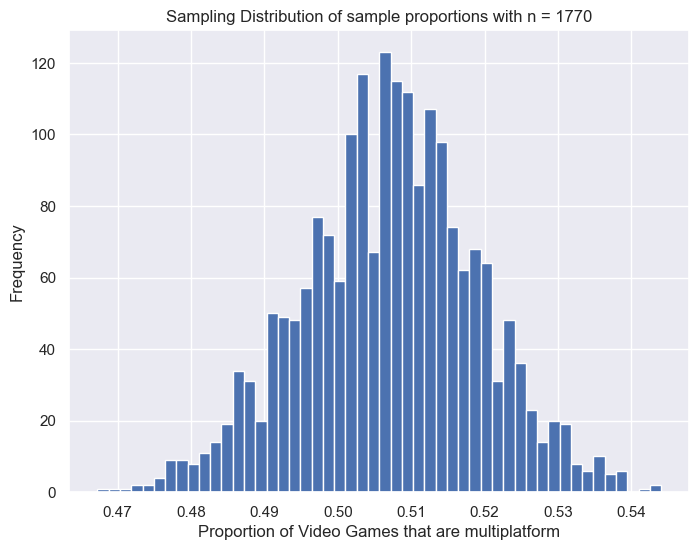

In [14]:
plt.figure(figsize=(8, 6))
plt.hist(sim_dist['p'], bins = 50)
plt.xlabel("Proportion of Video Games that are multiplatform")
plt.ylabel("Frequency")
plt.title("Sampling Distribution of sample proportions with n = 1770")
plt.show()

In [31]:
# Compute CI bounds

lower = sim_dist['p'].quantile(0.1)
upper = sim_dist['p'].quantile(0.9)
print(f'With a confidence level of 80%, our calculated confidence interval is ({lower}, {upper})')

With a confidence level of 80%, our calculated confidence interval is (0.4915254237288136, 0.5225988700564972)


### Interpretation 

The confidence interval suggests that approximately 50% of video games are multiplatform, indicating a balanced distribution across platforms.

## Hypothesis Testing Analytical Tasks

### Research Question

We tested whether the typical (median) review score of video games is lower than the industry benchmark of 75.

### Data Validation

We confirmed that the review score variable contains no missing values.

In [16]:
# Any Missing Values?
df["Review Score"].isna().sum()

np.int64(0)

### Descriptive Statistics

We examined the distribution of review scores and observed that the median is approximately 70, below the benchmark of 75.

In [17]:
# look at numerical summary of review score
df["Review Score"].describe()

count    1770.000000
mean       68.428814
std        13.894937
min        12.000000
25%        60.000000
50%        70.000000
75%        79.000000
max        98.000000
Name: Review Score, dtype: float64

<Axes: ylabel='Frequency'>

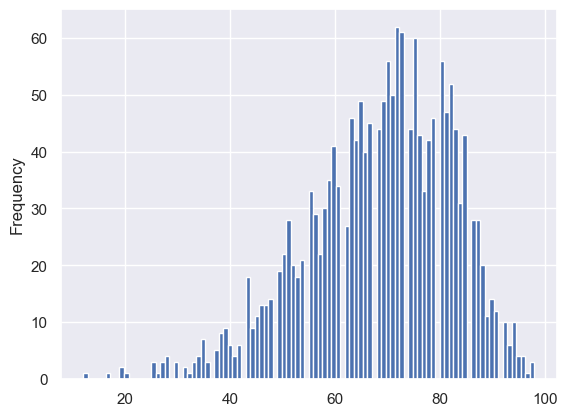

In [18]:
# make a histogram to observe the distribution of the data
df["Review Score"].plot.hist(bins=100)

### Hypothesis Testing

We tested :

    - H₀ : Median review score = 75
    - H₁ : Median review score < 75
The sample median was 70. 

In [19]:
# Our sample statistic
median_score = df["Review Score"].median()
print("Our sample median_score is:", median_score)

Our sample median_score is: 70.0


In [30]:
# shift data under null hypothesis
df["null_hyp"] = df["Review Score"] - df["Review Score"].median() + 75
df[["Title", "Review Score", "null_hyp"]]

,Title,Review Score,null_hyp
0,Super Mario 64 DS,85,90.0
1,Lumines: Puzzle Fusion,89,94.0
2,WarioWare Touched!,81,86.0
3,Hot Shots Golf: Open Tee,81,86.0
4,Spider-Man 2,61,66.0
...,...,...,...
1765,MotoGP 09/10,70,75.0
1766,Prison Break: The Conspiracy,41,46.0
1767,"Sakura Wars: So Long, My Love",74,79.0
1768,Record of Agarest War (The Really Naughty Limi...,71,76.0


In [21]:
# create a simulated sampling distribution with 5000 observations
# we will use a sample size of n = 1770.
median_review_scores = []
for i in range(5000):
    scores_sample = df["null_hyp"].sample(1770, replace = True).median()
    median_review_scores.append(scores_sample)
median_review_scores = pd.DataFrame({"x": median_review_scores})
median_review_scores

,x
0,75.0
1,75.0
2,74.0
3,75.0
4,75.0
...,...
4995,75.0
4996,75.0
4997,75.0
4998,76.0


In [32]:
# compute p-value
pval = (median_review_scores["x"] <= median_score).mean()
print(f'We calculated a p-value of {pval} from our simluated sampling distribution')

We calculated a p-value of 0.0 from our simluated sampling distribution


We obtained a p-value ≈ 0, indicating extremely strong evidence against the null hypothesis.

This suggests that the typical review score is significantly lower than 75.

## Conclusion

We estimate that approximately 50% of video games are multiplatform based on our confidence interval.

Additionally, hypothesis testing provides strong evidence that the typical review score is significantly below 75 (p-value ≈ 0).

Overall, this suggests that while multiplatform availability is common, video game performance tends to fall below the expected benchmark.